In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os
import re
from PIL import Image
import json
import torch
import torch.nn as nn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import unidecode

nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Text

## Data processing

In [3]:
# dev_set = pd.read_csv('/kaggle/input/2023sumdpl302m/devset_images_gt.csv')
test_meta = pd.read_csv('/kaggle/input/2023sumdpl302m/test.csv')
test_meta['id'] = test_meta['image_id'].astype(np.int64)
test_meta.drop((['image_id']), axis = 1, inplace = True)


In [4]:
test_meta.head()

,title,description,user_tags,id
0,"Flooded Parking Lot At Emily Fowler Library, A...",Denton Creek overflows its banks and floods Oa...,"project, slis 5715, spring 2009",3483809003
1,L'arc de Barà / The roman arch of Barà,Sembla que fou dedicat a August entorn l'any 1...,"arc, arc_de_berà, arch, archaeology, arco, arq...",3712805295
2,Highest point over the sea level that is reach...,NaN,NaN,379845620
3,Lagos after the rains,"After heavy rain, Lagos (Nigeria) was still fl...","africa, lagos, nigeria",7343264988
4,flooded Corley Ave,also a local black out due to the tree branch ...,"flood, storm, toronto",3843337492


In [5]:
# Open the JSON file
with open('/kaggle/input/2023sumdpl302m/devset_images_metadata.json') as json_file:
    # Load the JSON data
    data = json.load(json_file)

meta_dev = pd.DataFrame(data['images'])
meta_dev = meta_dev[['description','title','user_tags', 'image_id']]
meta_dev['id'] = meta_dev['image_id']
meta_dev.drop(['image_id'], axis=1, inplace = True)
meta_dev['id'] = meta_dev['id'].astype(np.int64)
meta_dev.head()

,description,title,user_tags,id
0,None,Biltmore Estate,"[2009 road trip, obrero road trip]",3519864665
1,None,Chand Minar,"[daulatabad, daulatabad fort, ellora, road trip]",4896119055
2,"After the flood, the boarded up stores bear up...",Uplifting Graffiti,"[cedarrapids, createsouthroadtrip2009, disaste...",3468473862
3,None,DSCF6487,"[cork, enchente, flood, ireland, irlanda]",4120853942
4,None,Oconoe river - flooded,"[athens georgia, brown, current, flood, mud, r...",4436083254


In [7]:
dev_gt = pd.read_csv('/kaggle/input/2023sumdpl302m/devset_images_gt.csv')
dev = pd.merge(meta_dev, dev_gt, on = 'id')
dev_gt.head()

,id,label
0,3519864665,0
1,4896119055,0
2,3468473862,0
3,4120853942,0
4,4436083254,0


In [68]:
english_stop_words = stopwords.words('english')
stemmer = PorterStemmer()

def text_normalize_dev(text):
    text = ' '.join(text)
    text = text.lower()
    text = unidecode.unidecode(text)
    text = text.strip()
    text = re.sub(r'[^\w\s]','',text)
    text = ' '.join([word for word in text.split(' ') if word not in english_stop_words])
    text = ' '.join([stemmer.stem(word) for word in text.split(' ')])
    
    return text

dev['user_tags'] = dev['user_tags'].apply(lambda x: text_normalize_dev(x))

In [151]:
def text_normalize_test(text):
    if isinstance(text, str):
        text = unidecode.unidecode(text)
        text = text.strip()
        text = re.sub(r'[^\w\s]','',text)
        text = ' '.join([word for word in text.split(' ') if word not in english_stop_words])
        text = ' '.join([stemmer.stem(word) for word in text.split(' ')])
    return text

# Apply the function to the 'user_tags' column
test_meta['user_tags'] = test_meta['user_tags'].apply(lambda x: text_normalize_test(x))

In [115]:
test_meta['user_tags'].head()

0                         project sli 5715 spring 2009
1    arc arc_de_bera arch archaeolog arco arqueolog...
2                                                  NaN
3                                  africa lago nigeria
4                                  flood storm toronto
Name: user_tags, dtype: object

In [109]:
dev['user_tags'].head()

0                      2009 road trip obrero road trip
1          daulatabad daulatabad fort ellora road trip
2    cedarrapid createsouthroadtrip2009 disast graf...
3                   cork enchent flood ireland irlanda
4    athen georgia brown current flood mud river sp...
Name: user_tags, dtype: object

## Building vocab

In [118]:
vocab = []
for sentence in dev['user_tags'].tolist():
    tokens = sentence.split()
    for token in tokens:
        if token not in vocab:
            vocab.append(token)
for sentence1 in test_meta['user_tags'].tolist():
    tokens = sentence.split()
    for token in tokens:
        if token not in vocab:
            vocab.append(token)
            
vocab.append('UNK')
vocab.append('PAD')
word_to_idx = {word: idx for idx,word in enumerate(vocab)}
vocab_size = len(vocab)

In [119]:
vocab_size 

13531

In [71]:
def transform(text, word_to_idx, max_seq_len):
    tokens = []
    for w in text.split():
        try:
            w_ids = word_to_idx[w]
        except:
            w_ids = word_to_idx['UNK']
        tokens.append(w_ids)
    
    if len(tokens) < max_seq_len:
        tokens += [word_to_idx['PAD']] * (max_seq_len - len(tokens))
    elif len(tokens) > max_seq_len:
        tokens = tokens[:max_seq_len]
    return tokens
 


In [86]:
val_size = 0.2

texts = dev['user_tags'].tolist()
labels = dev['label'].tolist()

X_train,X_val,y_train,y_val = train_test_split(
    texts, labels,
    test_size = val_size,
    random_state = 1,
    shuffle = True
)


### Build pytorch dataset

In [87]:
class FloodText(Dataset):
    def __init__(self,X,y,word_to_idx,max_seq_len,transform=None):
        self.texts = X
        self.labels = y
        self.word_to_idx = word_to_idx
        self.max_seq_len = max_seq_len
        self.transform = transform
        
    def __len__(self):
        return len(self.texts)
    def __getitem__(self,idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        if self.transform:
            text = self.transform(text, self.word_to_idx,self.max_seq_len)
            
        text = torch.tensor(text)
        
        return text, label

### DataLoader

In [169]:
max_seq_len = 32

train_dataset = FloodText(
    X_train,y_train,
    word_to_idx = word_to_idx,
    max_seq_len = max_seq_len,
    transform = transform
)
val_dataset = FloodText(
    X_val,y_val,
    word_to_idx = word_to_idx,
    max_seq_len = max_seq_len,
    transform = transform
) 


In [170]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 128,
    shuffle = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size = 8,
    shuffle=False
)


### Text model

In [171]:
class SentimentClassify(nn.Module):
    def __init__(self,vocab_size, embedding_dim, hidden_size,
                n_layers, n_classes, dropout_prob):
        super(SentimentClassify, self).__init__()
        self.embedding = nn.Embedding(vocab_size,embedding_dim)
        self.rnn = nn.LSTM(embedding_dim, hidden_size, n_layers, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, n_classes)
        
    def forward(self,x):
        x = self.embedding(x)
        x, (hn,cn) = self.rnn(x)
        x = x[:,-1,:]
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        
        return x

In [184]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = SentimentClassify(
    vocab_size=vocab_size,
    embedding_dim = 64,
    hidden_size = 64,
    n_layers = 2,
    n_classes = 2,
    dropout_prob = 0.3
).to(device)


In [186]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 50
# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

In [187]:
def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    train_losses = []
    val_losses = []
    train_accs = []  
    val_accs = []    

    for epoch in range(epochs):
        batch_train_losses = []
        correct_train = 0
        total_train = 0

        model.train()
        for idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_train_losses.append(loss.item())

            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        train_acc = 100 * correct_train / total_train
        train_accs.append(train_acc)

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f'EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tTrain acc: {train_acc:.2f}%\tVal loss: {val_loss:.4f}\tVal acc: {val_acc:.2f}%')

    return train_losses, val_losses, train_accs, val_accs

        

In [188]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    losses = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            losses.append(loss)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    loss = sum(losses)/len(losses)
    acc = correct*100 /total
    
    return loss, acc

In [189]:
train_losses, val_losses, train_accs, val_accs = fit(model,train_loader, val_loader, criterion, optimizer,device,epochs)


EPOCH 1:	Train loss: 0.6806	Train acc: 57.50%	Val loss: 0.6620	Val acc: 62.78%
EPOCH 2:	Train loss: 0.6613	Train acc: 63.21%	Val loss: 0.6614	Val acc: 63.07%
EPOCH 3:	Train loss: 0.6597	Train acc: 63.52%	Val loss: 0.6594	Val acc: 63.16%
EPOCH 4:	Train loss: 0.6588	Train acc: 63.64%	Val loss: 0.6591	Val acc: 63.16%
EPOCH 5:	Train loss: 0.6574	Train acc: 63.73%	Val loss: 0.6588	Val acc: 63.16%
EPOCH 6:	Train loss: 0.6585	Train acc: 63.61%	Val loss: 0.6584	Val acc: 63.16%
EPOCH 7:	Train loss: 0.6583	Train acc: 63.75%	Val loss: 0.6565	Val acc: 63.16%
EPOCH 8:	Train loss: 0.6558	Train acc: 63.80%	Val loss: 0.6562	Val acc: 63.16%
EPOCH 9:	Train loss: 0.6528	Train acc: 63.75%	Val loss: 0.6557	Val acc: 63.16%
EPOCH 10:	Train loss: 0.6537	Train acc: 63.75%	Val loss: 0.6550	Val acc: 63.16%
EPOCH 11:	Train loss: 0.6536	Train acc: 63.78%	Val loss: 0.6545	Val acc: 63.16%
EPOCH 12:	Train loss: 0.6519	Train acc: 63.75%	Val loss: 0.6542	Val acc: 63.16%
EPOCH 13:	Train loss: 0.6519	Train acc: 63.75%	Va

In [153]:
# Tokenize the text
tokenized_data = test_meta['user_tags'].apply(lambda x: x.split() if isinstance(x, str) else [])

# Convert tokens to indices using word_to_idx dictionary
indexed_data = [[word_to_idx[word] if word in word_to_idx else word_to_idx['UNK'] for word in tokens] for tokens in tokenized_data]

# Define the maximum sequence length
max_seq_len = 50

# Pad or truncate each sequence to ensure they all have the same length
padded_data = [tokens[:max_seq_len] + [word_to_idx['PAD']] * (max_seq_len - len(tokens)) for tokens in indexed_data]

# Convert the padded data to PyTorch tensor
tensor_data = torch.tensor(padded_data, dtype=torch.long)

# Print the shape of the tensor data
print(tensor_data.shape)

torch.Size([1320, 50])


In [190]:
output = model(tensor_data.to(device))

In [191]:
_, predicted = torch.max(output.data, 1)

In [158]:
test_meta['id']

0       3483809003
1       3712805295
2        379845620
3       7343264988
4       3843337492
           ...    
1315    6452132743
1316     244899140
1317    3073018258
1318      49525361
1319     537780925
Name: id, Length: 1320, dtype: int64

In [192]:
predicted_labels_np = predicted.cpu().numpy()

# Add predicted labels to the test DataFrame
test_meta['label'] = predicted_labels_np

# Save the DataFrame as a CSV file
test_meta[['id', 'label']].to_csv('test_with_labels.csv', index=False)

# Image

In [76]:
# import os
# import pandas as pd
# from PIL import Image

# # Load ground truth labels from CSV
# labels_df = pd.read_csv('/kaggle/input/2023sumdpl302m/devset_images_gt.csv')

# # Create a dictionary to map image filenames to their labels
# image_label_map = dict(zip(labels_df['id'], labels_df['label']))

# # Load images and corresponding labels
# devset_images = []
# devset_labels = []

# devset_image_dir = '/kaggle/input/2023sumdpl302m/devset_images/devset_images'
# for filename in os.listdir(devset_image_dir):
#     # Ignore files starting with '._'
#     if not filename.startswith('._'):
#         # Extract only the filename without the directory path
#         filename = os.path.basename(filename)
#         # Extract the image ID without the extension
#         image_id = os.path.splitext(filename)[0]
#         image_id = int(image_id)
#         # Check if the image ID is in the label map
#         if image_id in image_label_map:
#             image_path = os.path.join(devset_image_dir, filename)
#             image = Image.open(image_path)
#             devset_images.append(image)
#             devset_labels.append(image_label_map[image_id])

# # Check if the number of images matches the number of labels
# print("Number of images:", len(devset_images))
# print("Number of labels:", len(devset_labels))


In [96]:
class ImageDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.transform = transform
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        img_path = self.X[idx]
        label = self.y[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


In [104]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


# Load ground truth labels from CSV
labels_df = pd.read_csv('/kaggle/input/2023sumdpl302m/devset_images_gt.csv')

# Create a dictionary to map image filenames to their labels
image_label_map = dict(zip(labels_df['id'], labels_df['label']))

# Load images and corresponding labels
devset_images = []
devset_labels = []

devset_image_dir = '/kaggle/input/2023sumdpl302m/devset_images/devset_images'
for filename in os.listdir(devset_image_dir):
    # Ignore files starting with '._'
    if not filename.startswith('._'):
        # Extract only the filename without the directory path
        filename = os.path.basename(filename)
        # Extract the image ID without the extension
        image_id = os.path.splitext(filename)[0]
        image_id = int(image_id)
        # Check if the image ID is in the label map
        if image_id in image_label_map:
            image_path = os.path.join(devset_image_dir, filename)
            devset_images.append(image_path)
            devset_labels.append(image_label_map[image_id])

# Define image size
def transform(img, img_size=(224, 224)):
    # Resize and convert to NumPy array
    transform_resize = transforms.Resize(img_size)
    img = np.array(transform_resize(img))[..., :3]

    # Convert to PyTorch tensor and normalize
    transform_tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img = transform_tensor(img)

    # Data augmentation
    transform_augmentation = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
        transforms.RandomRotation(degrees=15),
        transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0), ratio=(0.8, 1.2)),
        transforms.RandomErasing(p=0.75, scale=(0.01, 0.3), ratio=(1.0, 1.0), value=0, inplace=True)
    ])

    # Apply data augmentation
    img = transform_augmentation(img)

    return img

# Create datasets
train_dataset = ImageDataset(devset_images, devset_labels, transform=transform)
valid_dataset = ImageDataset(devset_images, devset_labels, transform=transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)


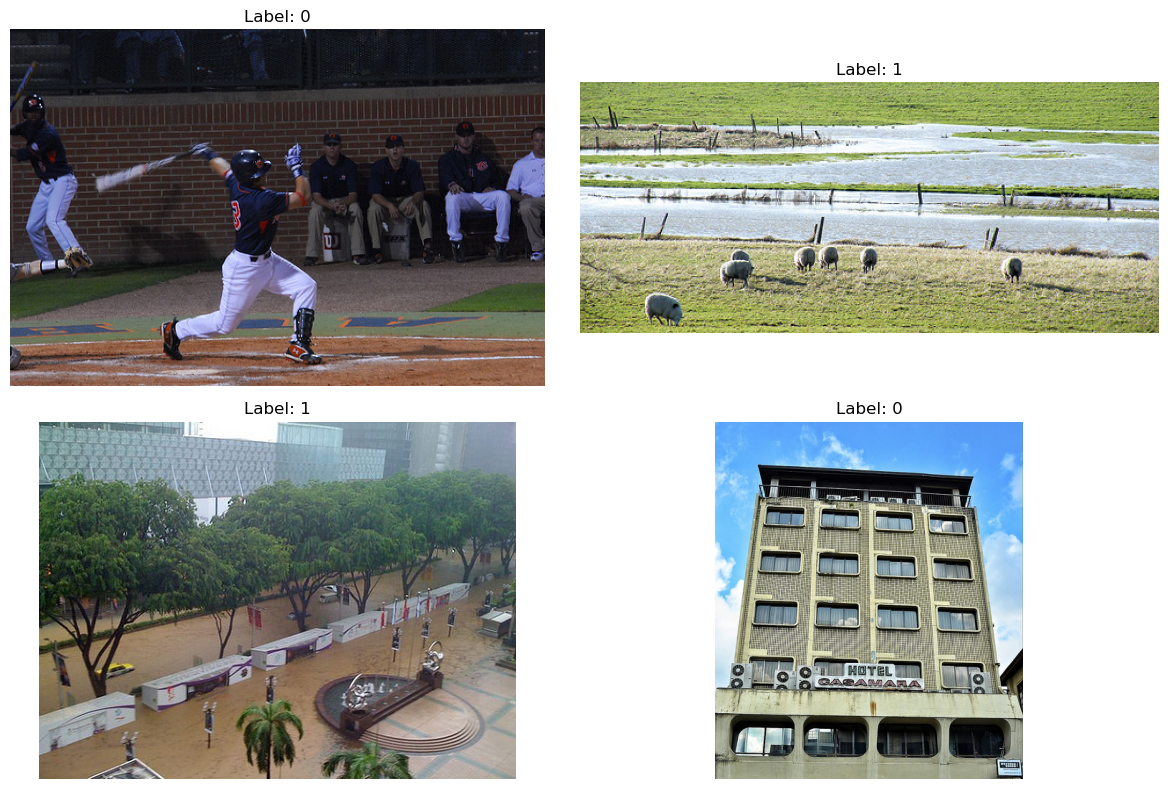

In [105]:
import matplotlib.pyplot as plt
import random

# Get four random indices
random_indices = random.sample(range(len(devset_images)), 4)

# Plot the random images
plt.figure(figsize=(12, 8))
for i, idx in enumerate(random_indices):
    img_path, label = devset_images[idx], devset_labels[idx]
    img = Image.open(img_path).convert('RGB')
    plt.subplot(2, 2, i+1)
    plt.imshow(np.array(img))
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [106]:
train_loader, valid_loader


(<torch.utils.data.dataloader.DataLoader at 0x792fc8de8a30>,
 <torch.utils.data.dataloader.DataLoader at 0x792fc8e16620>)

In [111]:
# train epoch
def train_epoch(model, optimizer, criterion, train_loader, device, epoch=0,log_interval=5):
  model.train()
  accs, losses = [],[]

  for idx, (inputs,labels) in enumerate(train_loader):
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()

    prediction = model(inputs)

    # Compute loss
    loss = criterion(prediction, labels)
    losses.append(loss)

    # Backward
    loss.backward()
    optimizer.step()

    _, predicted_labels = torch.max(prediction, 1)
    total_acc = (predicted_labels == labels).sum().item()
    acc = total_acc/labels.size(0)
    accs.append(acc)

    if idx % log_interval == 0 and idx>0:
      print("| epoch {:3d} | {:5d}/{:5d}batches | accuracy {:8.3f}".format(
        epoch, idx, len(train_loader), sum(accs) / len(accs)
    ))

  epoch_acc = sum(accs) / len(accs)
  epoch_loss = sum(losses) / len(losses)
  return epoch_acc, epoch_loss




In [112]:
def evaluate_epoch(model, criterion, valid_loader):
  model.eval()
  accs, losses = [],[]

  with torch.no_grad():
    for idx, (inputs,labels) in enumerate(valid_loader):
      inputs,labels = inputs.to(device), labels.to(device)

      predictions = model(inputs)

      loss = criterion(predictions, labels)
      losses.append(loss)

      _, predicted_labels = torch.max(predictions, 1)
      total_acc = (predicted_labels == labels).sum().item()
      acc = total_acc / labels.size(0)
      accs.append(acc)

  epoch_acc = sum(accs)/len(accs)
  epoch_loss = sum(losses)/len(losses)
  return epoch_acc, epoch_loss

In [120]:

# train model
def train(model, model_name, save_model, optimizer, criterion, train_loader, valid_loader, num_epochs, device):
    train_accs, train_losses = [], []
    eval_accs, eval_losses = [], []
    best_loss_eval = 100
    times = []

    for epoch in range(1, num_epochs + 1):
        epoch_start_time = time.time()

        # Training
        train_acc, train_loss = train_epoch(model, optimizer, criterion, train_loader, device, epoch)
        train_accs.append(train_acc)
        train_losses.append(train_loss)

        # Evaluation
        eval_acc, eval_loss = evaluate_epoch(model, criterion, valid_loader)
        eval_accs.append(eval_acc)
        eval_losses.append(eval_loss)

        # Save best model
        if eval_loss < best_loss_eval:
            torch.save(model.state_dict(), save_model + f'/{model_name}.pt')

        times.append(time.time() - epoch_start_time)

        # Print loss, acc end epoch
        print("-" * 59)
        print("| End of epoch {:3d} | Time: {:5.2f}s | Train Accuracy {:8.3f} | Train Loss {:8.3f} "
              "| Valid Accuracy {:8.3f} | Valid Loss {:8.3f}".format(epoch, time.time() - epoch_start_time,
                                                                     train_acc, train_loss, eval_acc, eval_loss))
        print("-" * 59)

    # Load best model
    model.load_state_dict(torch.load(save_model + f'/{model_name}.pt'))
    model.eval()
    
    metrics = {
        'train_accuracy': train_accs,
        'train_loss': train_losses,
        'valid_accuracy': eval_accs,
        'valid_loss': eval_losses,
        'time': times
    }
    return model, metrics



In [121]:
finetuning_model = models.resnet18(
    weights = models.ResNet18_Weights.IMAGENET1K_V1
)

num_layers =11
# Freeze 50 layers in FE
for idx, para in enumerate(finetuning_model.parameters()):
  if idx<num_layers:
    para.requires_grad = False

in_features = finetuning_model.fc.in_features
finetuning_model.fc = nn.Linear(in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fine_tuning_model = finetuning_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(finetuning_model.parameters(), lr=0.0001)

num_epochs =10
save_model = './model'
os.makedirs(save_model, exist_ok = True)
model_name = 'fine_tuning_model'

finetuning_model, fine_tuning_metrics = train(
    fine_tuning_model,model_name, save_model, optimizer, criterion, train_loader,
    valid_loader, num_epochs, device
)

| epoch   1 |     5/  165batches | accuracy    0.474
| epoch   1 |    10/  165batches | accuracy    0.534
| epoch   1 |    15/  165batches | accuracy    0.590
| epoch   1 |    20/  165batches | accuracy    0.626
| epoch   1 |    25/  165batches | accuracy    0.657
| epoch   1 |    30/  165batches | accuracy    0.678
| epoch   1 |    35/  165batches | accuracy    0.689
| epoch   1 |    40/  165batches | accuracy    0.707
| epoch   1 |    45/  165batches | accuracy    0.714
| epoch   1 |    50/  165batches | accuracy    0.722
| epoch   1 |    55/  165batches | accuracy    0.727
| epoch   1 |    60/  165batches | accuracy    0.735
| epoch   1 |    65/  165batches | accuracy    0.734
| epoch   1 |    70/  165batches | accuracy    0.737
| epoch   1 |    75/  165batches | accuracy    0.741
| epoch   1 |    80/  165batches | accuracy    0.746
| epoch   1 |    85/  165batches | accuracy    0.746
| epoch   1 |    90/  165batches | accuracy    0.746
| epoch   1 |    95/  165batches | accuracy   

In [134]:

class TestImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_names = os.listdir(image_dir)
        self.transform = transform
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        if not image_name.startswith('._'):
            image_path = os.path.join(self.image_dir, image_name)
            image = Image.open(image_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, image_name

# Directory containing test set images
test_image_dir = '/kaggle/input/2023sumdpl302m/testset_images/testset_images'

# Define image size
img_size = 224

# Define transformations
transform_resize = transforms.Resize((img_size, img_size))
transform_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create test dataset
test_dataset = TestImageDataset(test_image_dir, transform=transform_resize)

# Create test loader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Print number of test images
print("Number of test images:", len(test_dataset))


Number of test images: 2602


In [135]:
fine_tuning_model.eval()

# Define a list to store the predictions
predictions = []

# Iterate over the test_loader to make predictions
for images, image_names in test_loader:
    # Move images to the device
    images = images.to(device)
    
    # Perform forward pass
    with torch.no_grad():
        outputs = fine_tuning_model(images)
    
    # Get the predicted class for each image
    _, predicted = torch.max(outputs, 1)
    
    # Convert tensor to list and extend the predictions list
    predictions.extend(predicted.cpu().numpy())

# Print the predictions
print(predictions)

TypeError: object of type 'NoneType' has no len()